## K-means

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 
from sklearn.datasets import make_blobs 
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

We'll create our own dataset

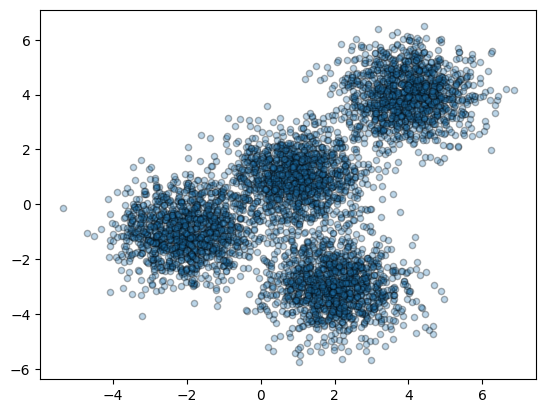

In [3]:
np.random.seed(0)
X, y = make_blobs(n_samples=5000, centers=[[4,4], [-2, -1], [2, -3], [1, 1]], cluster_std=0.9)
plt.scatter(X[:, 0], X[:, 1], marker='.',alpha=0.3,ec='k',s=80)

In [25]:
model = KMeans(init='k-means++', n_clusters=4, n_init=12)
model.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",12
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [26]:
labels = model.labels_
labels

array([2, 1, 1, ..., 3, 2, 2], shape=(5000,), dtype=int32)

In [27]:
clusterCenters = model.cluster_centers_
clusterCenters

array([[ 0.96900523,  0.98370298],
       [ 1.99741008, -3.01666822],
       [-2.03743147, -0.99782524],
       [ 3.97334234,  3.98758687]])

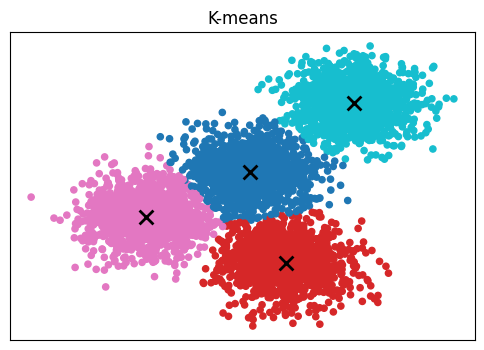

In [28]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(X[:,0], X[:,1], c=labels, cmap='tab10', s=20)
ax.scatter(clusterCenters[:,0], clusterCenters[:,1], c='black', marker='x', s=100, linewidths=2)
ax.set_title("K-means")
ax.set_xticks(())
ax.set_yticks(())
plt.show()

### Customer Segmentation
Customer segmentation is the practice of partitioning a customer base into groups of individuals that have similar characteristics. It is a significant strategy as a business can target these specific groups of customers and effectively allocate marketing resources.

In [29]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/Cust_Segmentation.csv")
df

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2
...,...,...,...,...,...,...,...,...,...,...
845,846,27,1,5,26,0.548,1.220,NaN,NBA007,6.8
846,847,28,2,7,34,0.359,2.021,0.0,NBA002,7.0
847,848,25,4,0,18,2.802,3.210,1.0,NBA001,33.4
848,849,32,1,12,28,0.116,0.696,0.0,NBA012,2.9


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      850 non-null    int64  
 1   Age              850 non-null    int64  
 2   Edu              850 non-null    int64  
 3   Years Employed   850 non-null    int64  
 4   Income           850 non-null    int64  
 5   Card Debt        850 non-null    float64
 6   Other Debt       850 non-null    float64
 7   Defaulted        700 non-null    float64
 8   Address          850 non-null    str    
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(5), str(1)
memory usage: 71.5 KB


Address is Categorical, Kmeans dont work with categorical so we can encode it or right now drop it

In [ ]:
df.drop('Address',axis=1, inplace=True)
df.dropna(inplace=True)

Normalization is needed in K-means

In [45]:
X = df.values[:,1:]    #leave customer id
scaled_X = StandardScaler().fit_transform(X)

In [53]:
k=3
model = KMeans(init='k-means++', n_clusters=k, n_init=12)
model.fit(X)
labels = model.labels_

In [54]:
df["Customer_Labels_Kmeans"] = labels

For Centroid Values

In [55]:
df.groupby("Customer_Labels_Kmeans").mean()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Customer_Labels_Kmeans,,,,,,,,,
0,439.80226,32.775895,1.632768,6.169492,30.642185,1.003795,2.090910,0.284369,10.146893
1,403.56129,41.103226,1.916129,15.135484,81.122581,3.024935,5.605258,0.180645,10.848387
2,374.00000,44.785714,3.000000,17.857143,219.714286,6.115429,11.546357,0.285714,8.064286


Find Distribution of Customers based on their education, age, income. Markersize will tell education

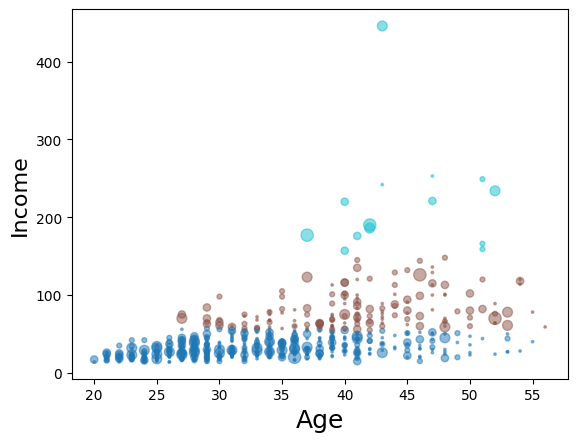

In [56]:
area = np.pi * (df['Edu'])**2
plt.scatter(df['Age'], df['Income'], s=area, c=labels.astype(float), cmap='tab10', alpha=0.5)
plt.xlabel('Age', fontsize=18)
plt.ylabel('Income', fontsize=16)
plt.show()

Lets Group with these 3 features and cluster labels

Text(0.5, 1.02, 'Pairwise Scatter Plot with K-means Clusters')

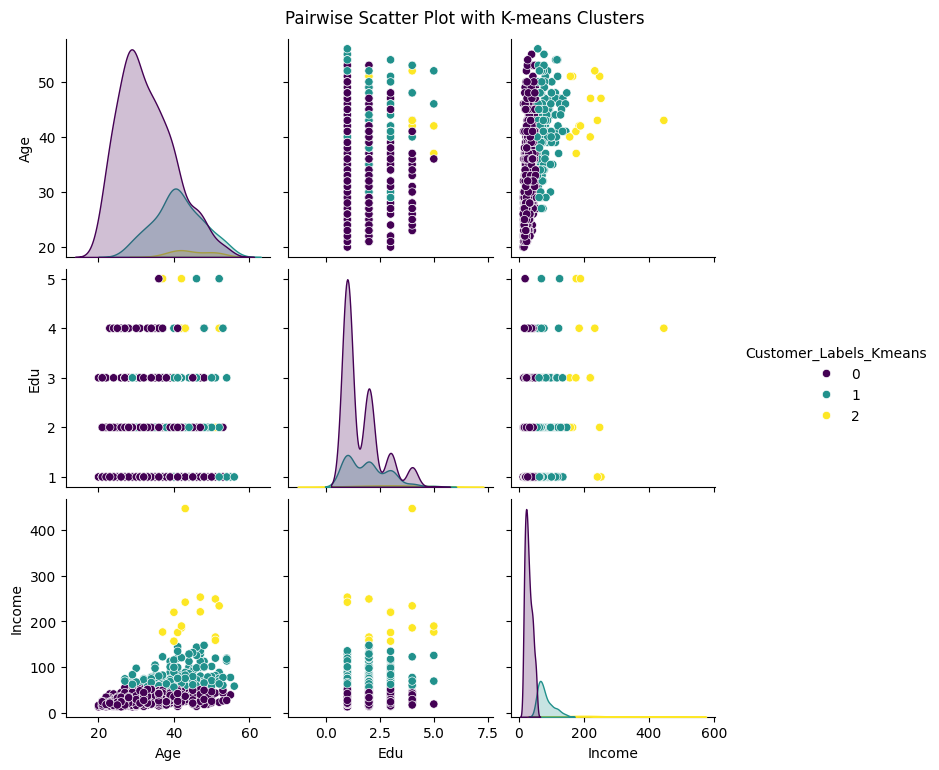

In [57]:
group_df = df[['Age', 'Edu','Income','Customer_Labels_Kmeans']]
sns.pairplot(group_df, hue='Customer_Labels_Kmeans', palette='viridis', diag_kind='kde')
plt.suptitle('Pairwise Scatter Plot with K-means Clusters', y=1.02)

### KDEs
- Age: Cluster 0 has most people with age b/w 20-40, Cluster 2 has elder people and Cluster 3 has only few old people
- Education: Cluster 0 has most people with lower-to-mid education dominating, Cluster 1 show a similar pattern but with less people and Cluster 2 cant be interpreted.
- Income: Cluster 0 has most people, sided at lower income, Cluster 1 has few people towards mid income and Cluster 2 has only few, skewed at high income

### Scatterplots
- Age vs Edu: Clusters are not seperated easily
- Age vs Income: Best indicator, Cluster 0 people sit below with low income, Cluster 1 are slightly above and Cluster 2 is sparse with high income
- Edu vs Income: Clusters not seperated

In [59]:
df.groupby('Customer_Labels_Kmeans').agg(['mean','count'])

Customer Id              Age             Edu        \
                              mean count       mean count      mean count   
Customer_Labels_Kmeans                                                      
0                        439.80226   531  32.775895   531  1.632768   531   
1                        403.56129   155  41.103226   155  1.916129   155   
2                        374.00000    14  44.785714    14  3.000000    14   

                       Years Employed            Income       Card Debt        \
                                 mean count        mean count      mean count   
Customer_Labels_Kmeans                                                          
0                            6.169492   531   30.642185   531  1.003795   531   
1                           15.135484   155   81.122581   155  3.024935   155   
2                           17.857143    14  219.714286    14  6.115429    14   

                       Other Debt       Defaulted       DebtIncomeRatio        
                             mean count      mean count            mean count  
Customer_Labels_Kmeans                                                         
0                        2.090910   531  0.284369   531       10.146893   531  
1                        5.605258   155  0.180645   155       10.848387   155  
2                       11.546357    14  0.285714    14        8.064286    14

- Cluster 0: Age around 32, Education around lower, Income also lowest
- Cluster 1 Age around 41, Education around mid level, Income is decent
- Cluster 2: Age around 44, Education is high level and so is income

- So we can group the 3 clusters as: Poor, Middle-class, Rich